# Recovering Planetary Transit Signals in Active PLATO-like Stars

## Objective

The goal of this project is to investigate whether machine learning can detect planetary transit signals in the presence of stellar activity.

We use the publicly available PSLS simulator to generate synthetic PLATO-like light curves containing:

- Stellar rotation
- Starspots
- Flares
- Noise
- Planetary transits

These simulated light curves are then used to create a labeled dataset for machine learning classification.

## Installing PSLS

The simulator was installed in a Linux environment.

Main dependencies:

- Python
- NumPy
- SciPy
- PyYAML
- Matplotlib

In [1]:
pip install numpy scipy matplotlib pyyaml pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import yaml
import matplotlib.pyplot as plt

In [3]:
import os
os.chdir("/home/zilani/Downloads/psls")

## Prototype Simulations

Before generating a large dataset, four prototype YAML configurations were created.

These prototype configurations represent:

- Class 0 : Quiet star, no planet
- Class 1 : Activity only
- Class 2 : Planet + mild activity
- Class 3 : Planet + strong activity

The purpose was to verify that PSLS correctly generates the expected light-curve behavior before scaling to a larger dataset.

## Class 0: Quiet Star Without a Planet

The first prototype simulation represents a quiet stellar light curve without any injected planetary transit or significant stellar activity.

This class serves as the baseline case and allows us to verify the simulator output under minimal variability conditions.

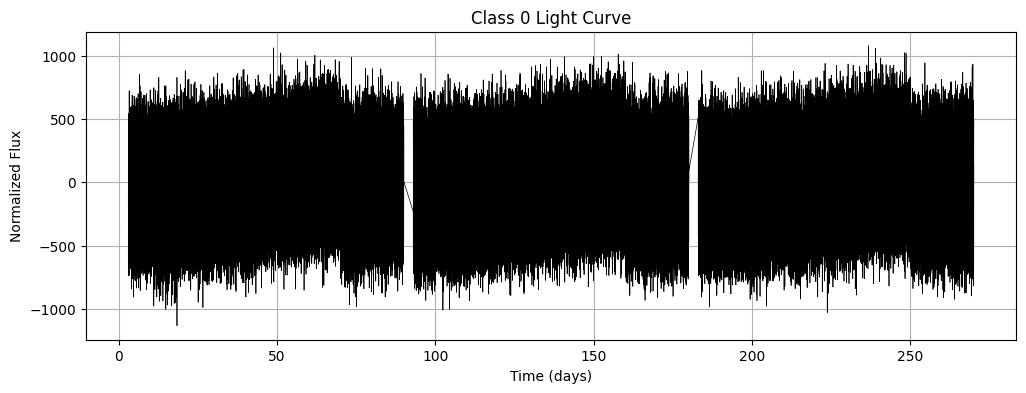

Saved: /home/zilani/Downloads/psls/prototype/class0_output/class0_lightcurve.png


In [4]:
import subprocess
from pathlib import Path
import shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

subprocess.run([
    "python",
    "/home/zilani/Downloads/psls/psls.py",
    "/home/zilani/Downloads/psls/prototype/class0.yaml"
])

output_dir = Path(
    "/home/zilani/Downloads/psls/prototype/class0_output"
)

output_dir.mkdir(exist_ok=True)

base = Path("/home/zilani/Downloads/psls")

files_to_move = [
    "0000000000.dat",
    "0000000000.modes",
    "0000000000.txt"
]

for f in files_to_move:

    src = base / f
    dst = output_dir / f

    if src.exists():
        shutil.move(str(src), str(dst))
        dat_file = (
"/home/zilani/Downloads/psls/prototype/class0_output/0000000000.dat"
)

data = np.loadtxt(dat_file)

time = data[:,0] / 86400.0
flux = data[:,1]
flux = flux / np.median(flux)

plt.figure(figsize=(12,4))

plt.plot(
    time,
    flux,
    color="black",
    linewidth=0.5
)

plt.xlabel("Time (days)")
plt.ylabel("Normalized Flux")

plt.title("Class 0 Light Curve")

plt.grid(True)

png_file = (
"/home/zilani/Downloads/psls/prototype/class0_output/class0_lightcurve.png"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", png_file)

## Class 1: Stellar Activity Only

In this prototype, stellar variability is introduced through activity-related effects such as spots and rotational modulation, while no planetary transit is injected.

This class is important because stellar activity can mimic planetary signals and produce false positives.

/home/zilani/Downloads/psls/spotintime.py:102: RuntimeWarning: invalid value encountered in arccos
  delta = np.arccos(1. / (np.tan(alpha) * np.tan(bet)))


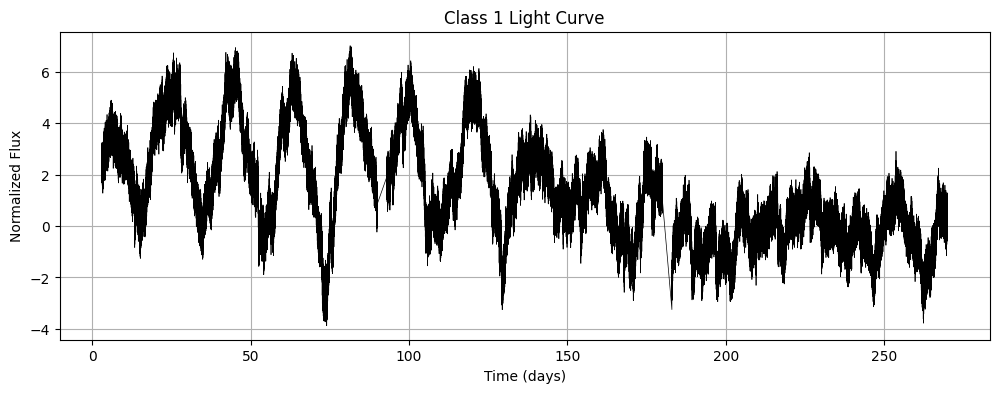

Saved: /home/zilani/Downloads/psls/prototype/class1_output/class1_lightcurve.png


In [5]:
import subprocess
from pathlib import Path
import shutil
import numpy as np
import matplotlib.pyplot as plt

subprocess.run([
    "python",
    "/home/zilani/Downloads/psls/psls.py",
    "/home/zilani/Downloads/psls/prototype/class1.yaml"
])

output_dir = Path(
    "/home/zilani/Downloads/psls/prototype/class1_output"
)

output_dir.mkdir(exist_ok=True)

base = Path("/home/zilani/Downloads/psls")

files_to_move = [
    "0000000001.dat",
    "0000000001.modes",
    "0000000001.txt"
]

for f in files_to_move:
    src = base / f
    dst = output_dir / f

    if src.exists():
        shutil.move(str(src), str(dst))

dat_file = (
"/home/zilani/Downloads/psls/prototype/class1_output/0000000001.dat"
)

data = np.loadtxt(dat_file)

time = data[:,0] / 86400.0
flux = data[:,1]
flux = flux / np.median(flux)

plt.figure(figsize=(12,4))
plt.plot(
    time,
    flux,
    color="black",
    linewidth=0.5
)

plt.xlabel("Time (days)")
plt.ylabel("Normalized Flux")
plt.title("Class 1 Light Curve")

plt.grid(True)

png_file = (
    "/home/zilani/Downloads/psls/prototype/class1_output/class1_lightcurve.png"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", png_file)

## Class 2: Planet with Mild Stellar Activity

This configuration contains both a transiting planet and a moderate level of stellar activity.

The objective is to investigate whether planetary transit signals remain detectable when low-level stellar variability is present.

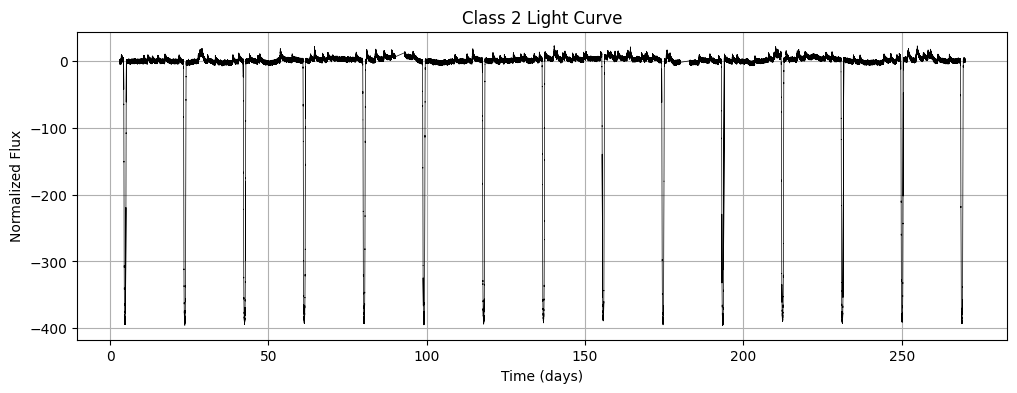

Saved: /home/zilani/Downloads/psls/prototype/class2_output/class2_lightcurve.png


In [6]:
import subprocess
from pathlib import Path
import shutil
import numpy as np
import matplotlib.pyplot as plt

subprocess.run([
    "python",
    "/home/zilani/Downloads/psls/psls.py",
    "/home/zilani/Downloads/psls/prototype/class2.yaml"
])

output_dir = Path(
    "/home/zilani/Downloads/psls/prototype/class2_output"
)

output_dir.mkdir(exist_ok=True)

base = Path("/home/zilani/Downloads/psls")

files_to_move = [
    "0000000002.dat",
    "0000000002.modes",
    "0000000002.txt"
]
for f in files_to_move:
    src = base / f
    dst = output_dir / f

    if src.exists():
        shutil.move(str(src), str(dst))

dat_file = (
"/home/zilani/Downloads/psls/prototype/class2_output/0000000002.dat"
)

data = np.loadtxt(dat_file)

time = data[:,0] / 86400.0
flux = data[:,1]
flux = flux / np.median(flux)

plt.figure(figsize=(12,4))
plt.plot(
    time,
    flux,
    color="black",
    linewidth=0.5
)

plt.xlabel("Time (days)")
plt.ylabel("Normalized Flux")
plt.title("Class 2 Light Curve")

plt.grid(True)

png_file = (
    "/home/zilani/Downloads/psls/prototype/class2_output/class2_lightcurve.png"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", png_file)

## Class 3: Planet with Strong Stellar Activity

This scenario combines planetary transits with strong stellar activity.

Such light curves are the most challenging for detection algorithms because stellar variability can partially hide or distort transit signatures.

/home/zilani/Downloads/psls/spotintime.py:102: RuntimeWarning: invalid value encountered in arccos
  delta = np.arccos(1. / (np.tan(alpha) * np.tan(bet)))


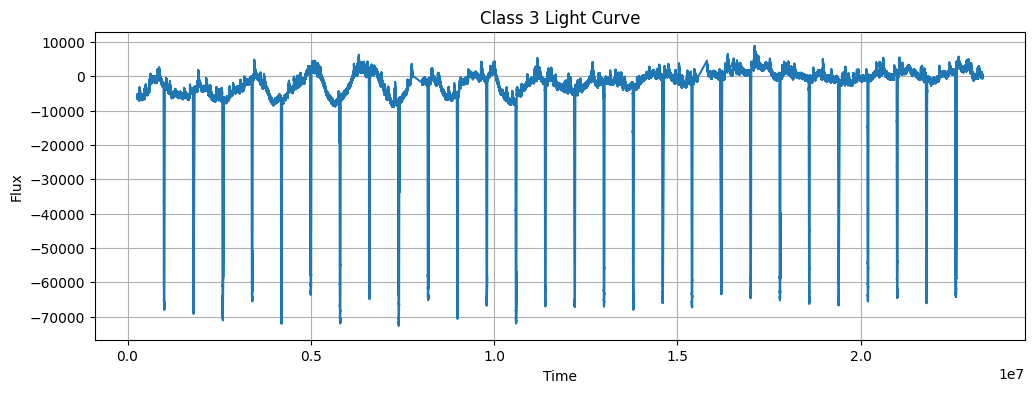

Saved: /home/zilani/Downloads/psls/prototype/class3_output/class3_lightcurve.png


In [7]:
import subprocess
from pathlib import Path
import shutil
import numpy as np
import matplotlib.pyplot as plt

subprocess.run([
    "python",
    "/home/zilani/Downloads/psls/psls.py",
    "/home/zilani/Downloads/psls/prototype/class3.yaml"
])

output_dir = Path(
    "/home/zilani/Downloads/psls/prototype/class3_output"
)

output_dir.mkdir(exist_ok=True)

base = Path("/home/zilani/Downloads/psls")

files_to_move = [
    "0000000003.dat",
    "0000000003.modes",
    "0000000003.txt"
]

for f in files_to_move:
    src = base / f
    dst = output_dir / f

    if src.exists():
        shutil.move(str(src), str(dst))

dat_file = (
"/home/zilani/Downloads/psls/prototype/class3_output/0000000003.dat"
)

data = np.loadtxt(dat_file)

time = data[:,0]
flux = data[:,1]

plt.figure(figsize=(12,4))
plt.plot(time, flux)

plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Class 3 Light Curve")

plt.grid(True)

png_file = (
    "/home/zilani/Downloads/psls/prototype/class3_output/class3_lightcurve.png"
)

plt.savefig(
    png_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", png_file)

# Automated Dataset Generation

After validating the prototype simulations, the next step was to scale the dataset.

Python scripts were developed to automatically generate large numbers of YAML configuration files by varying relevant stellar and planetary parameters.

A total of 250 configurations were generated for each class, producing 1000 simulations overall.

In [8]:
!python generate_yaml_class_0.py

✅ Class 0: 250 YAML files generated successfully!


In [9]:
!python generate_yaml_class_1.py

250 YAML files created.


In [10]:
!python generate_yaml_class_2.py

 250 CLASS-2 YAML files generated correctly!


In [11]:
!python generate_yaml_class_3.py

250 YAML files generated with YOUR parameter ranges!


# Bulk Light Curve Simulation

The generated YAML files were processed using PSLS.

Each configuration file produced a synthetic PLATO-like light curve, which was stored as a .dat file for later analysis and machine-learning applications.

In [ ]:
import os
import subprocess

yaml_dir = "/home/zilani/Downloads/psls/generated_yaml_class_0"

yaml_files = sorted([
    f for f in os.listdir(yaml_dir)
    if f.endswith(".yaml")
])

for yaml_file in yaml_files:

    yaml_path = os.path.join(yaml_dir, yaml_file)

    print(f"Running {yaml_file}")

    subprocess.run(
        [
            "python",
            "/home/zilani/Downloads/psls/psls.py",
            yaml_path
        ]
    )

print("DONE")

In [ ]:
import os
import subprocess

yaml_dir = "/home/zilani/Downloads/psls/generated_yaml_class_1"

yaml_files = sorted([
    f for f in os.listdir(yaml_dir)
    if f.endswith(".yaml")
])

for yaml_file in yaml_files:

    yaml_path = os.path.join(yaml_dir, yaml_file)

    print(f"Running {yaml_file}")

    subprocess.run(
        [
            "python",
            "/home/zilani/Downloads/psls/psls.py",
            yaml_path
        ]
    )

print("DONE")

In [ ]:
import os
import subprocess

yaml_dir = "/home/zilani/Downloads/psls/generated_yaml_class_2"

yaml_files = sorted([
    f for f in os.listdir(yaml_dir)
    if f.endswith(".yaml")
])

for yaml_file in yaml_files:

    yaml_path = os.path.join(yaml_dir, yaml_file)

    print(f"Running {yaml_file}")

    subprocess.run(
        [
            "python",
            "/home/zilani/Downloads/psls/psls.py",
            yaml_path
        ]
    )

print("DONE")

In [ ]:
import os
import subprocess

yaml_dir = "/home/zilani/Downloads/psls/generated_yaml_class_3"

yaml_files = sorted([
    f for f in os.listdir(yaml_dir)
    if f.endswith(".yaml")
])

for yaml_file in yaml_files:

    yaml_path = os.path.join(yaml_dir, yaml_file)

    print(f"Running {yaml_file}")

    subprocess.run(
        [
            "python",
            "/home/zilani/Downloads/psls/psls.py",
            yaml_path
        ]
    )

print("DONE")

In [ ]:
for c in range(4):

    yaml_dir = f"/home/zilani/Downloads/psls/generated_yaml_class_{c}"
    dat_dir  = f"/home/zilani/Downloads/psls/output_class{c}"

    n_yaml = len([
        f for f in os.listdir(yaml_dir)
        if f.endswith(".yaml")
    ])

    n_dat = len([
        f for f in os.listdir(dat_dir)
        if f.endswith(".dat")
    ])

    print(f"Class {c}: YAML={n_yaml}, DAT={n_dat}")

# Metadata Construction

Machine-learning algorithms require structured information describing each simulated light curve.

Therefore, a metadata table was constructed by extracting relevant stellar and planetary parameters from the YAML files and associating them with the corresponding simulated light curves.

In [ ]:
import os
import yaml
import numpy as np
import pandas as pd

rows = []

for cls in range(4):

    yaml_dir = f"/home/zilani/Downloads/psls/generated_yaml_class_{cls}"
    dat_dir  = f"/home/zilani/Downloads/psls/output_class{cls}"

    yaml_files = sorted(
        [f for f in os.listdir(yaml_dir)
         if f.endswith(".yaml")]
    )

    dat_files = sorted(
        [f for f in os.listdir(dat_dir)
         if f.endswith(".dat")]
    )

    print(
        f"Class {cls}:",
        len(yaml_files),
        "yaml,",
        len(dat_files),
        "dat"
    )

    for yaml_file, dat_file in zip(yaml_files, dat_files):

        try:

            yaml_path = os.path.join(
                yaml_dir,
                yaml_file
            )

            dat_path = os.path.join(
                dat_dir,
                dat_file
            )

            with open(yaml_path) as f:
                cfg = yaml.safe_load(f)

            lc = np.loadtxt(dat_path)

            flux = lc[:,1]

            row = {

                "filename": dat_file,

                "class": cls,

                "planet_label":
                    int(cfg["Transit"]["Enable"]),

                "has_planet":
                    int(cfg["Transit"]["Enable"]),

                "has_activity":
                    int(cfg["Activity"]["Enable"]),

                "flux_mean":
                    np.mean(flux),

                "flux_std":
                    np.std(flux),

                "amplitude":
                    np.max(flux)-np.min(flux),

                "n_points":
                    len(flux),

                "planet_radius":
                    cfg["Transit"].get(
                        "PlanetRadius",0
                    ),

                "orbital_period":
                    cfg["Transit"].get(
                        "OrbitalPeriod",0
                    ),

                "impact_parameter":
                    cfg["Transit"].get(
                        "ImpactParameter",0
                    ),

                "flare_amplitude":
                    cfg["Activity"]
                    .get("Flare",{})
                    .get("Amplitude",0),

                "spot_radius_mean":
                    np.mean(
                        cfg["Activity"]
                        .get("Spot",{})
                        .get("Radius",[0])
                    ),

                "spot_latitude_mean":
                    np.mean(
                        cfg["Activity"]
                        .get("Spot",{})
                        .get("Latitude",[0])
                    ),

                "spot_lifetime_mean":
                    np.mean(
                        cfg["Activity"]
                        .get("Spot",{})
                        .get("Lifetime",[0])
                    ),

                "stellar_rotation_period":
                    cfg["Star"].get(
                        "SurfaceRotationPeriod",
                        0
                    ),

                "tau":
                    cfg["Activity"].get(
                        "Tau",
                        0
                    )
            }

            rows.append(row)

        except Exception as e:

            print(
                "ERROR:",
                cls,
                yaml_file,
                e
            )

metadata_v2 = pd.DataFrame(rows)

In [ ]:
metadata_v2.shape

In [ ]:
metadata_v2.groupby("class")[["has_planet","has_activity"]].mean()

In [ ]:
metadata_v2.groupby("class")[[
    "planet_radius",
    "flare_amplitude",
    "tau",
    "spot_radius_mean"
]].mean()

In [ ]:
metadata_v2.to_csv(
    "metadata_v2.csv",
    index=False
)

print("metadata_v2.csv saved")

# Summary

In this phase of the project:

- Four prototype simulations were created and verified.
- Automated scripts generated 250 configurations for each class.
- PSLS was used to generate 1000 synthetic PLATO-like light curves.
- A metadata table containing physical and simulation parameters was constructed.

The resulting dataset is now ready for feature extraction, exploratory analysis, and machine-learning classification.